## This section covers analyzing the overall output data and extracting the relevant JR regions from the Logan/HMMER outputs
1. Filter for the L1-annotated ORFs from the stop-stop ORF finding process
    * subgoal1: do some summary statistics of which hits are present/absent, mean length etc.
    * subgoal2: compare differences of HMM hits from pfam and in-house L1
2. extract list of the L1 annotated ORFs, align to make sure everything looks right
3. run more granular JR HMM against these L1s, look for full sequences
    * filter for ones that have hits against all 6 models
    * extract the amino acid coordinates, and the nucleic acid coordinates, run against blastn to look for novelty
4. create list of candidate libraries for pathracer analysis

In [9]:
! pip install rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [30]:
#conda install r::r-tidyverse

In [3]:
 %reload_ext rpy2.ipython

In [8]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [4]:
%%R
#switch to R kernel
#logan3
#i love tidyverse
library(tidyverse)
#function to parse the domtbl output
hmmsearch_clean <- function(input_domtbl){
  input_domtbl_scan <- read.table(input_domtbl, sep = "",  header = F, fill = T) %>% na.omit() %>% .[,1:22]  
  colnames(input_domtbl_scan) <- c("query_acc", "misc", "qlen", "pfam", "pfam_acc", "tlen", "eval_full", "score_full", "bias_full", "#", "of", 
                                   "c_eval", "i_eval", "score_one", "bias_one", "hmmcoord_from", "hmmcoord_to", "alicoord_from", "alicoord_to", "envcoord_from", "envcoord_to", "acc")
  input_domtbl_scan$query_acc_clean <- sub("_[^_]+$", "", input_domtbl_scan$query_acc)
  input_domtbl_scan <- type.convert(input_domtbl_scan, as.is = TRUE)
  return(input_domtbl_scan)
}

#import from hmmer
feb_7_pv <- hmmsearch_clean("feb_7_pv_fil_form.aa.domtbl")
feb_7_pv$contig <- sub("([A-Za-z0-9]+_[A-Za-z0-9]+).*", "\\1", feb_7_pv$query_acc)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.3     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In addition: Warning message:
In grSoftVersion() :
  unable to load shared object '/home/jshen/anaconda3/lib/R/modules//R_X11.so':
  libXt.so.6: cannot open shared object file: No such file or directory


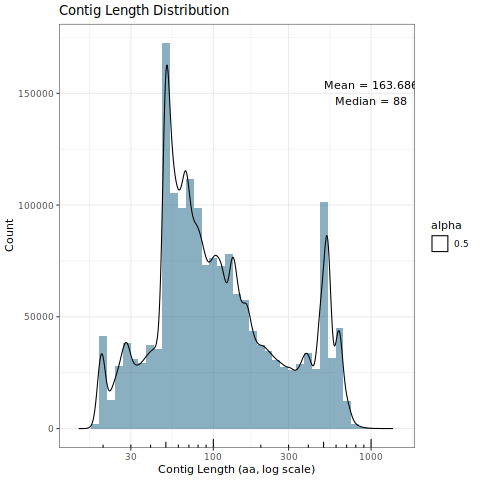

In [11]:
%%R
#P1 sub1: basic summary statistics of hmmer file, what is going on etc.
#some graphs
#for contig length
a1 <- mean(feb_7_pv$qlen)
b1 <- median(feb_7_pv$qlen)

ggplot(feb_7_pv, aes(x=qlen)) +
  geom_histogram(binwidth = 0.05, alpha=0.5, fill="#156082") +
  geom_density(aes(y=0.05*..count.., alpha=0.5)) +
  scale_x_log10() +
  annotate("text", x = 1000, y = 150000, label = paste0("Mean = ", round(a1, digits = 3), "\n", "Median = ", round(b1, digits = 3))) +
  theme_bw() +
  ggtitle("Contig Length Distribution") +
  xlab("Contig Length (aa, log scale)") +
  ylab("Count") + annotation_logticks(sides = "b")


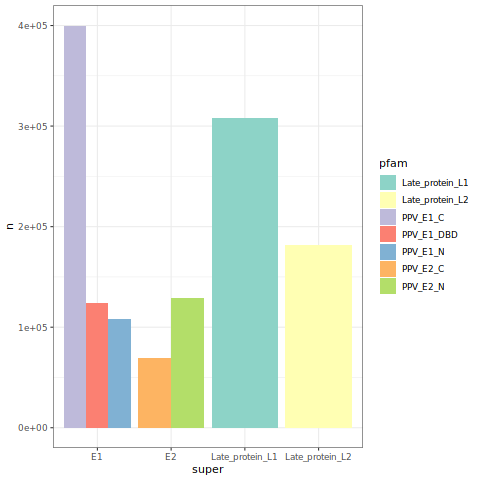

In [12]:
%%R
#make "superfamily" for some of the categories
feb_7_pv_count <- feb_7_pv %>%
  count(pfam) %>%
  group_by(pfam)

feb_7_pv_count$super <- feb_7_pv_count$pfam %>% sub(".*E1.*.", "E1", .) %>% 
  sub(".*E2.*.", "E2", .)

#look at distribution of hits
feb_7_pv_count_fil <- filter(feb_7_pv_count, super  %in% c("E1", "E2", "Late_protein_L1", "Late_protein_L2"))

ggplot(feb_7_pv_count_fil, aes(fill=pfam, y=n, x=super)) + 
  geom_bar(position="dodge", stat="identity") +
  theme_bw() +
  scale_fill_brewer(palette = "Set3")

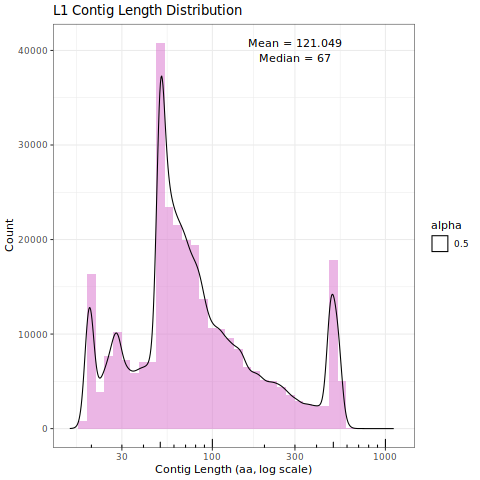

In [13]:
%%R
#filter for those hit against the Pfam L1
feb_7_pv_L1 <- filter(feb_7_pv, pfam == "Late_protein_L1")
length(unique(feb_7_pv_L1$query_acc))
#307441
length(unique(feb_7_pv_L1$query_acc)) - length(unique(feb_7_pv$query_acc))
#1058413
#for L1
a2 <- mean(feb_7_pv_L1$qlen)
b2 <- median(feb_7_pv_L1$qlen)

ggplot(feb_7_pv_L1, aes(x=qlen)) +
  geom_histogram(binwidth = 0.05, alpha=0.5, fill="#D86ECC") +
  geom_density(aes(y=0.05*..count.., alpha=0.5)) +
  scale_x_log10() +
  annotate("text", x = 300, y = 40000, label = paste0("Mean = ", round(a2, digits = 3), "\n", "Median = ", round(b2, digits = 3))) +
  theme_bw() +
  ggtitle("L1 Contig Length Distribution") +
  xlab("Contig Length (aa, log scale)") +
  ylab("Count") + annotation_logticks(sides = "b")

In [49]:
%%R
#P1 sub2: PVfam vs my HMM
#slight differences in hit number
feb_7_pv_count[3,]
feb_7_pv_count[12,]
#going to leave it at that, not super important atm.

pfam,n,super
<chr>,<int>,<chr>
Late_protein_L1,307685,Late_protein_L1


pfam,n,super
<chr>,<int>,<chr>
ncbi_and_novel_L1_JR,263262,ncbi_and_novel_L1_JR


In [50]:
%%R
#P2 extract list of the L1 annotated ORFs, align to make sure everything looks right
#generate table of these names to be used to extract sequences from the ORF file
write.table(feb_7_pv_L1$query_acc, "feb_7_pv_L1_orf.txt", quote = F, col.names = F, row.names = F, sep = "\t")

In [16]:
%%bash
#P3, investigate for completeness
#dos2unix feb_7_pv_L1_orf.txt
head feb_7_pv_L1_orf.txt

#using this, should be able to extract the ORFs from the giant ORF file with seqkit grep. (no -n flag, since there are spaces in the fasta headers of getorf output
#"/home/rnalab/js/pv_3/feb_7_pv_fil_form.aa" <- in compressed version on GH
seqkit grep -f "/home/rnalab/js/pv_3/feb_7_pv_L1_orf.txt" "/home/rnalab/js/pv_3/feb_7_pv_fil_form.aa" -o feb_7_pv_fil_form_L1.aa
#[INFO] 307441 patterns loaded from file

#sanity check
grep ">" "/home/rnalab/js/pv_3/feb_7_pv_fil_form_L1.aa" | wc -l
#307441

#annotate for full length sequences with jrHMM
hmmsearch --F1 0.01 -T 20 --domtblout feb_7_pv_fil_form_L1_BI.domtbl "/home/rnalab/js/hmms/hmmv3/ncbi_and_novel_L1_BI.hmm" "/home/rnalab/js/pv_3/feb_7_pv_fil_form_L1.aa" 

SRR6757665_35583_ka_f_631.306_L_827921_L_1211658__63
SRR8360571_46505_ka_f_888.320_L_973140_L_974109_L_409772_L_409773__175
SRR8360572_181804_ka_f_418.409_L_340944_L_340988_L_1859166__64
SRR8360573_263994_ka_f_1454.758_L_1303806_L_1743013_L_1713738__71
SRR8360574_465725_ka_f_241.165_L_322172__175
SRR8360575_39324_ka_f_606.947_L_1814528_L_1814529__71
SRR8360576_71555_ka_f_1194.092_L_1064730_L_1583379_L_1694785__176
SRR11207298_63445_ka_f_6.700__94
ERR8027536_29808_ka_f_70.592_L_29808_L_29808__349
SRR12520342_2308_ka_f_18.642_L_609_L_986__252


In [27]:
%%R
#P3 cont.
#next, tabulate which are "full"
feb_7_pv_L1_BI <- hmmsearch_clean("feb_7_pv_fil_form_L1_BI.domtbl")

#extract some extra information
feb_7_pv_L1_BI$contig <- sub("([A-Za-z0-9]+_[A-Za-z0-9]+).*", "\\1", feb_7_pv_L1_BI$query_acc)
feb_7_pv_L1_BI$library <- sub("_.*", "\\1", feb_7_pv_L1_BI$contig)

#record those with all regions intact
feb_7_pv_L1_BI_mat <- feb_7_pv_L1_BI %>%
  count(query_acc, pfam) %>%
  spread(pfam, n, fill = 0)

feb_7_pv_L1_BI_mat_full <- feb_7_pv_L1_BI_mat %>%
  filter(if_all(ncbi_and_novel_L1_B:ncbi_and_novel_L1_I, ~ .x > 0))

#write out the list of full contigs (for a really cursed extraction)
write.table(select(feb_7_pv_L1_BI_mat_full, query_acc), "feb_7_pv_L1_BI_mat_full.list", quote = F, col.names = F, row.names = F)

#do a REALLY messy extraction of the nucleotide for downstream coordinates
L1_BI_list <- feb_7_pv_L1_BI_mat_full$query_acc

feb_7_pv_L1_full <- filter(feb_7_pv_L1_BI, query_acc %in% L1_BI_list)

L1_full_list <- select(feb_7_pv_L1_full, pfam, contig)
L1_full_list$pfam <- c("L1_full")
L1_full_list <- L1_full_list[!duplicated(L1_full_list), ]

#get the most "leftmost" coordinate
feb_7_pv_L1_envcoord_from <- feb_7_pv_L1_full %>% 
  group_by(query_acc) %>% 
  slice_min(n = 1, envcoord_from) %>% 
  select(query_acc, envcoord_from)

#get the most "rightmost" coordinate
feb_7_pv_L1_envcoord_to <- feb_7_pv_L1_full %>% 
  group_by(query_acc) %>% 
  slice_max(n = 1, envcoord_to) %>% 
  select(query_acc, envcoord_to)

feb_7_pv_L1_envcoords <- left_join(feb_7_pv_L1_envcoord_from, feb_7_pv_L1_envcoord_to, by = "query_acc")
#calculate nucleotide positions
feb_7_pv_L1_envcoords$nuc_from <- feb_7_pv_L1_envcoords$envcoord_from*2 + (feb_7_pv_L1_envcoords$envcoord_from - 3)
feb_7_pv_L1_envcoords$nuc_to <- feb_7_pv_L1_envcoords$envcoord_to*3 - 1

write.table(feb_7_pv_L1_envcoords, "feb_7_pv_L1_envcoords.bed", quote = F, col.names = F, row.names = F)


In [ ]:
%%bash
#P3 - incredibly cursed extraction
#the general idea is that it's incredibly hard to go from aa -> nuc and retain coordinate information
#so i create an XY problem for myself, where i extract the nucleotide sequence from the ORFs first, then the specific coordinates at which the jrhmm hits
#this solves the issue of strandedness, where it's not really possible to get this back from aa coordinates

#get orfs (with info on nucleotide positions) from the orf output file
seqkit grep -f feb_7_pv_L1_BI_mat_full.list "/home/rnalab/js/pv_3/feb_7_pv_fil_form.aa" -o feb_7_pv_L1_BI_mat_full_nuc_coords.list
#sanity check
grep ">" "/home/rnalab/js/pv_3/feb_7_pv_L1_BI_mat_full_nuc_coords.list" | wc -l
#14048

#get only the headers to make a bedfile with
grep ">" feb_7_pv_L1_BI_mat_full_nuc_coords.list > feb_7_pv_L1_BI_mat_full_nuc_coords_from_orf.list

head "/home/rnalab/js/pv_3/feb_7_pv_fil_form.nuc"
#>DRR000743_10070_ka_f_57.108_L_203283_L_203283_
#need to be able to reference to this

head feb_7_pv_L1_BI_mat_full_nuc_coords_from_orf.list
#>DRR008484_85337_ka_f_102.602_L_1661434_L_1661435_L_1661435_L_5671379__364 [1956 - 376] (REVERSE SENSE)
#current format looks like this

#to make bed file:
#just fuck me up
sed -e 's/ $/_/' -e 's/(REVERSE SENSE)_/\t(-)/' -e 's/_$/\t(+)/' -e  's/__.*\[/\_ [/' -e 's/[][]//g' -e 's/ - /\t/' -e 's/[[:blank:]]+/,/g' -e 's/>//'
#get the nucleotide sequences for novelty search
awk '{print $1, $2, $3}' "/home/rnalab/js/pv_3/feb_7_pv_fil_form.aa.bed" | awk 'OFS="\t" {if($2>$3) print $1, $3-1, $2, ".", ".", "-"; else print $1, $2-1, $3, ".", ".", "+"}' | ../bedtools getfasta -s -fi "/home/rnalab/js/pv_3/feb_7_pv_fil_form.nuc" -bed - > feb_7_pv_L1_nuc_from_orf.fa

#get the nucleotide coordinates of the B-I regions
#need to clean all of this up so it plays nice
#holy crapola
sed 's/__.?\t/_\t/' feb_7_pv_L1_envcoords.bed > feb_7_pv_L1_envcoords_form.bed
sed 's/:/_\t /' "/home/rnalab/js/pv_3/feb_7_pv_L1_nuc_from_orf.fa" > feb_7_pv_L1_nuc_from_orf_name.fa
sed 's/__[^\t]*\t/_\t/' "/home/rnalab/js/pv_3/feb_7_pv_L1_envcoords.bed" > "/home/rnalab/js/pv_3/feb_7_pv_L1_envcoords_form.bed"

#finally run bedtools
bedtools getfasta -fi "/home/rnalab/js/pv_3/feb_7_pv_L1_nuc_from_orf_name.fa" -bed "/home/rnalab/js/pv_3/feb_7_pv_L1_envcoords_form.bed" > feb_7_L1_nuc_hmmer_env.fa
#sanity
head "/home/rnalab/js/pv_3/feb_7_L1_nuc_hmmer_env.fa"
# >DRR008484_85337_ka_f_102.602_L_1661434_L_1661435_L_1661435_L_5671379_:96-1316
# ACACCCGTGGCGAGGGTACAAAGTACCGATGAATATGTTGAACGCACCAATATTTATTATCATGCATTTACTGATCGTCTGTTAACTGTAGGACATCCTTATTTCAATATATTCAATAATGATGGTAACAAGTTAGAAGTGCCCAAAGTATCAGGAAATCAGCATAGGGTATTTCGATTGCGCTTGCCAGACCCTAACAGATTTGCTCTGGCAGACATGTCTGTTTATAATCCTGATAAGGAAAGATTGGTATGGGCCATTACAGGCCTGGAAATAGGTAGGGGACAGCCTTTGGGTGTTGGTACTAGTGGTCATCCATTATTTAACAAGTTTAATGATACTGAAAATGGTAACAAATATACCAATACTAGTACAGACGATAGACAAAACATTTCCTTTGATCCCAAACAGCTTCAGATGTTTATTATAGGCTGTACCCCTTGCATTGGTGAGCACTGGGACAGAGCAACAGCATGTGTTGAGGATGAGCAGGTGGGCAGATGTCCTCCTATTGAATTAGTGAATACTTACATTCAGGATGGTGATATGGCAGATATAGGATACGGAAATTTAAATTTTAAGGCCTTACAGCAAAATCGCTCTGATGTTAGTTTGGATATAGTAGATGAAATTTGCAAATATCCAGACTTTTTAAAGATGCAAAATGATGTATATGGTGATGCTTGCTTTTTTTATGCTAGGCGAGAGCAGTGTTATGCCAGGCACTTTTTTGTTCGTGGTGGTAAGCCTGGTGATGATATTCCTGCACAGCAAATAGATGATGGTAAACTTAAAAATGAATTTTATATACCAGCTGCTGGTGGGCAGGCTCAAGGTCAACTTGGAAATTCCATGTATTTCCCAACTGTGAGTGGATCATTAGTATCAAGTGATGCCCAATTATTTAATAGGCCCTTCTGGCTACAAAGAGCACAGGGTCATAATAATGGCATCTTATGGGGTAATCAATTATTTGTGACTGTATTAGACAACACACGAAATACTAATTTCAGTATTGCTGTGTATAGTGAGCAAGGCAAAATACAGGACATTACCAATTATGATTCCTCCAAGTTTCGAGAATATCAGCGGCATGTGGAGGAATATGAGGTATCGCTGATTTTGCAGTTATGCAAAATCCCTTTGAAGCCTGAGGTACTGGCCCACATCAATGCAATGAATCCCGCCATTTTAGATGACTGGCAATTAGGGTTTATACC
# >DRR008488_1890236_ka_f_67.306_L_9305031_L_9322717_L_9305031_L_12666519_:96-1316
# ACACCCGTGGCGAGGGTACAAAGTACCGATGAATATGTTGAACGCACCAATATTTATTATCATGCATTTACTGATCGTCTGTTAACTGTAGGACATCCTTATTTCAATATATTCAATAATGATGGTAACAAGTTAGAAGTGCCCAAAGTATCAGGAAATCAGCATAGGGTATTTCGATTGCGCTTGCCAGACCCTAACAGATTTGCTCTGGCAGACATGTCTGTTTATAATCCTGATAAGGAAAGATTGGTATGGGCCATTACAGGCCTGGAAATAGGTAGGGGACAGCCTTTGGGTGTTGGTACTAGTGGTCATCCATTATTTAACAAGTTTAATGATACTGAAAATGGTAACAAATATACCAATACTAGTACAGACGATAGACAAAACATTTCCTTTGATCCCAAACAGCTTCAGATGTTTATTATAGGCTGTACCCCTTGCATTGGTGAGCACTGGGACAGAGCAACAGCATGTGTTGAGGATGAGCAGGTGGGCAGATGTCCTCCTATTGAATTAGTGAATACTTACATTCAGGATGGTGATATGGCAGATATAGGATACGGAAATTTAAATTTTAAGGCCTTACAGCAAAATCGCTCTGATGTTAGTTTGGATATAGTAGATGAAATTTGCAAATATCCAGACTTTTTAAAGATGCAAAATGATGTATATGGTGATGCTTGCTTTTTTTATGCTAGGCGAGAGCAGTGTTATGCCAGGCACTTTTTTGTTCGTGGTGGTAAGCCTGGTGATGATATTCCTGCACAGCAAATAGATGATGGTAAACTTAAAAATGAATTTTATATACCAGCTGCTGGTGGGCAGGCTCAAGGTCAACTTGGAAATTCCATGTATTTCCCAACTGTGAGTGGATCATTAGTATCAAGTGATGCCCAATTATTTAATAGGCCCTTCTGGCTACAAAGAGCACAGGGTCATAATAATGGCATCTTATGGGGTAATCAATTATTTGTGACTGTATTAGACAACACACGAAATACTAATTTCAGTATTGCTGTGTATAGTGAGCAAGGCAAAATACAGGACATTACCAATTATGATTCCTCCAAGTTTCGAGAATATCAGCGGCATGTGGAGGAATATGAGGTATCGCTGATTTTGCAGTTATGCAAAATCCCTTTGAAGCCTGAGGTACTGGCCCACATCAATGCAATGAATCCCGCCATTTTAGATGACTGGCAATTAGGGTTTATACC
# >DRR013317_15_ka_f_115.034_L_473_L_205_:27-1202
# GTGCCTGTGTCTAAGGTTGTAAGCACTGATGAATATGTGTCACGCACAAGCATTTATTATTATGCTGGCAGTTCCAGACTTTTGGCTGTTGGCAATCCATATTTTTCCATCAAAAGTCCCAATAACAATAAAAAAGTATTAGTTCCCAAGGTATCAGGCTTACAGTATAGGGTCTTTAGGGTGCGTTTACCTGATCCCAATAAATTTGGTTTTCCTGATACATCTTTTTATAACCCTGATACACAACGTTTGGTCTGGGCATGTGTAGGCCTTGAAATAGGTAGGGGACAGCCATTGGGTGTTGGCGTAAGTGGTCATCCTTATTTCAATAAATTTGATGACACTGAAACCAGTAACAGATATCCCGCACAGCCAGGGTCTGATAACAGGGAATGCTTATCTATGGATTATAAACAAACACAATTATGTTTAATTGGCTGTAAACCTCCCACTGGTGAGCATTGGGGTAAAGGTGTTGCCTGTAACAATAATGCAGCTGCTACTGATTGTCCTCCATTGGAACTTTTTAATTCTATTATTGAGGATGGTGACATGGTAGATACAGGGTTTGGATGCATGGACTTTGGTACATTGCAGGCTAATAAAAGTGATGTGCCTATTGATATTTGTAACAGTACATGCAAATATCCAGATTATTTAAAAATGGCCAGTGAACCTTATGGGGATAGTTTGTTCTTTTTTCTTAGACGTGAGCAGATGTTTGTTAGGCACTTTTTTAATAGGGCCGGAAAACTTGGCGAGGCTGTCCCGGATGACCTTTATATTAAAGGGTCCGGTAATACTGCAGTTATCCAAAGTAGTGCATTTTTTCCAACTCCTAGTGGCTCTATGGTTACCTCAGAATCACAATTATTTAATAAGCCTTATTGGCTACAGCGTGCACAAGGTCATAACAATGGCATTTGCTGGGGCAATCAGTTATTTGTTACCGTAGTTGATACCACTCGTAGCACTAATATGACATTATGCACTGAAGTAACTAAGGAAGGTACATATAAAAATGATAATTTTAAGGAATATGTACGTCATGTTGAAGAATATGACTTACAGTTTGTTTTTCAGCTTTGCAAAATTACACTAACTGCAGAGATAATGACATATATACATACTATGGATTCCAATATTTTGGAGGACTGGCAATTTGGTTTAACACC
# >DRR013318_0_ka_f_37.840_L_0_L_0_:129-1304
# GTGCCTGTGTCTAAGGTTGTAAGCACTGATGAATATGTGTCACGCACAAGCATTTATTACTATGCTGGCAGTTCCAGACTTTTGGCTGTTGGCAATCCATATTTTTCCATCAAAAGTCCCAATAACAATAAAAAAGTATTAGTTCCCAAGGTATCAGGCTTACAGTATAGGGTCTTTAGGGTGCGTTTACCTGATCCCAATAAATTTGGTTTTCCTGATACATCTTTTTATAACCCTGATACACAACGTTTGGTCTGGGCATGTGTAGGCCTTGAAATAGGTAGGGGACAGCCATTGGGTGTTGGCGTAAGTGGTCATCCTTATTTCAATAAATTTGATGACACTGAAACCAGTAACAGATATCCCGCACAGCCAGGGTCTGATAACAGGGAATGCTTATCTATGGATTATAAACAAACACAATTATGTTTAATTGGCTGTAAACCTCCCACTGGTGAGCATTGGGGTAAAGGTGTTGCCTGTAACAATAATGCAGCTGCTACTGATTGTCCTCCATTGGAACTTTTTAATTCTATTATTGAGGATGGTGACATGGTAGATACAGGGTTTGGATGCATGGACTTTGGTACATTGCAGGCTAATAAAAGTGATGTGCCTATTGATATTTGTAACAGTACATGCAAATATCCAGATTATTTAAAAATGGCCAGTGAACCTTATGGGGATAGTTTGTTCTTTTTTCTTAGACGTGAGCAGATGTTTGTTAGACACTTTTTTAATAGGGCTGGAAAACTTGGCGAGGCTGTCCCGGATGACCTTTATATTAAAGGGTCCGGTAATACTGCAGTTATACAAAGTAGTGCATTTTTTCCAACTCCTAGTGGCTCTATGGTTACCTCAGAATCACAATTATTTAATAAGCCTTATTGGCTACAGCGTGCACAAGGTCATAACAATGGCATTTGCTGGGGCAATCAGTTATTTGTTACCGTGGTTGATACCACTCGTAGCACTAATATGACATTATGCACTGAAGTAACTAAGGAAGGTACATATAAAAATGATAATTTTAAGGAATATGTACGTCATGTTGAAGAATATGACTTACAGTTTGTTTTTCAGCTTTGCAAAATTACACTAACTGCAGAGATAATGACATATATACATACTATGGATTCAAATATTTTGGAGGACTGGCAATTTGGTTTAACACC
# >DRR013319_8_ka_f_41.304_L_254_L_38_:27-1217
# GTACCTGTCTCTAAGGTTGTAAGCACTGATGAGTATGTGTCTCGCACAAGCATCTATTATTATGCAGGCAGTTCTCGATTACTGACAGTAGGACATCCCTATTTTTCTATTAAAAACACCAGTAGTGGTAATGGTAAAAAAGTTTTAGTTCCCAAGGTGTCTGGCCTGCAATACAGGGTATTTAGAATTAAATTGCCGGACCCTAATAAATTTGGTTTTCCAGATACATCTTTTTATAACCCAGAAACCCAAAGGTTGGTGTGGGCCTGTACAGGCTTGGAAATCGGTAGGGGACAGCCTTTAGGTGTGGGTATTAGTGGGCATCCTTTATTAAACAAGTTTGATGATACTGAAACCAGTAACAAATATGCTGGTAAACCTGGTATAGATAATAGGGAATGTTTATCTATGGATTATAAGCAAACTCAGTTATGCATTTTAGGATGCAAACCTCCTATAGGTGAACATTGGGGTAAGGGAACCCCTTGTAATAATAATTCAGGAAATCCTGGGGATTGTCCTCCCCTACAACTCATTAACAGTGTAATACAGGATGGGGACATGGTAGATACAGGATTTGGTTGCATGGATTTTAATACCTTGCAAGCTAGTAAAAGTGATGTGCCCATTGATATATGTAGCAGTGTATGTAAGTATCCAGATTATTTGCAAATGGCTAGCGAGCCATATGGTGACAGTTTGTTCTTTTTTCTTAGACGTGAGCAAATGTTTGTTAGACACTTTTTTAATAGGGCCGGTACCTTAGGTGACCCTGTGCCAGGTGATTTATATATACAAGGGTCTAACTCTGGCAATACTGCCACTGTACAAAGCAGTGCTTTTTTTCCTACTCCTAGTGGTTCTATGGTAACCTCAGAATCCCAATTATTTAATAAACCGTACTGGTTACAACGTGCGCAGGGCCACAATAATGGCATATGTTGGGGCAATCAGTTGTTTGTCACAGTTGTGGATACCACTCGTAGCACTAACATGACTTTATGTGCTGAGGTGAAAAAGGAAAGCACATATAAAAATGAAAATTTTAAGGAATACCTTCGTCATGGCGAGGAATTCGATTTACAATTTATTTTTCAATTGTGCAAGATTACATTAACAGCTGATGTTATGACATATATTCATAAGATGGATGCCACTATTTTAGAGGACTGGCAATTTGGCCTTACCCC

#sort and cluster
seqkit sort -l -r feb_7_L1_nuc_hmmer_env.fa > feb_7_L1_nuc_hmmer_env_sorted.fa
usearch --cluster_smallmem feb_7_L1_nuc_hmmer_env_sorted.fa -id 0.90 -centroids feb_7_L1_nuc_hmmer_env_sorted_centroids.fa -uc feb_7_L1_nuc_hmmer_env_sorted_clusters.uc


In [ ]:
%%bash
#P4, finally search for "novelty"
#using NCBI database
#https://www.ncbi.nlm.nih.gov/IEB/ToolBox/CPP_DOC/lxr/source/src/app/blast/update_blastdb.pl
#don't run this lol
update_blastdb.pl nt
#blastn date: feb 11, 2025

#run nucleotide search against the centroids at 90% nt identity
blastn -num_threads 16 -query feb_7_L1_nuc_hmmer_env_sorted_centroids.fa -db nt \
-outfmt "6 qseqid qstart qend qlen qstrand \
       sseqid  sstart send slen \
       pident evalue \
       staxids sscinames" \
-max_target_seqs 5 -out feb_7_L1_nuc_hmmer_env.tsv

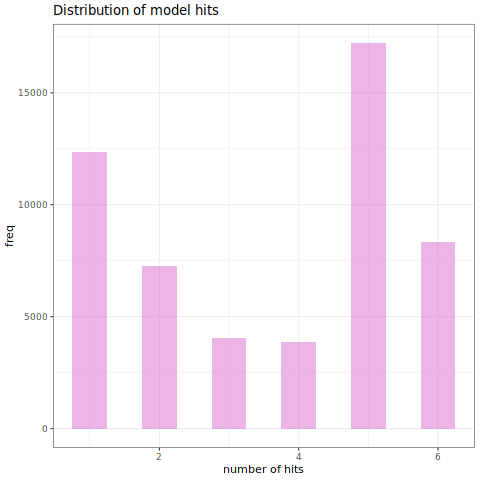

In [29]:
%%R
#P5, make list of candidate pathracer libraries
#look for those that have all hits somewhere in libraries -1, but remove those that are known to be full
L1_BI_list <- feb_7_pv_L1_BI_mat_full$query_acc
feb_7_pv_L1_BI_lib <- filter(feb_7_pv_L1_BI, !query_acc %in% L1_BI_list)
#change into matrix
feb_7_pv_L1_BI_lib_tab <- feb_7_pv_L1_BI_lib %>%
  count(library, pfam) %>%
  spread(pfam, n, fill = 0)

#convert to yes/no matrix, e.g., 0/1 for A/P
feb_7_pv_L1_BI_lib_logi <- feb_7_pv_L1_BI_lib_tab
feb_7_pv_L1_BI_lib_logi[-1] <- as.data.frame(+ sapply(feb_7_pv_L1_BI_lib_logi[-1], as.logical))
#sum rows
feb_7_pv_L1_BI_lib_logi$pa_sums <- rowSums(feb_7_pv_L1_BI_lib_logi[,2:7])
#sloppy histogram

ggplot(feb_7_pv_L1_BI_lib_logi, aes(x=pa_sums)) +
  geom_histogram(binwidth = 0.5, alpha=0.5, fill="#D86ECC") +
  theme_bw() +
  ggtitle("Distribution of model hits") +
  xlab("number of hits") +
  ylab("freq")

In [ ]:
%%R
#P5, output list of pathracer libraries for downstream running
#select those that have => 3 hits, I think any less than that it's unlikely to retrieve any full sequencee
#tbh 3 is probably generous
feb_7_pv_L1_BI_lib_logi_4 <- filter(feb_7_pv_L1_BI_lib_logi, pa_sums > 2)

#have to extract list of expected contigs from each library
feb_7_pv_L1_BI_partials <- filter(feb_7_pv_L1_BI, !query_acc %in% feb_7_pv_L1_full)

#get the numbers
lib_sums <- feb_7_pv_L1_BI_lib_logi_4[c(1, 8)]

feb_7_pv_L1_BI_partials_sums <- left_join(feb_7_pv_L1_BI_partials, lib_sums, by = "library")

#function to write a text file with the list of contigs hit for L1 in the given library
write_file_func <- function(lib){
  library_filtered <- filter(feb_7_pv_L1_BI_partials_sums, library == lib)
  write.table(unique(library_filtered$query_acc), paste("2024.02.11.subgraph/", lib, "_list.txt", sep = ""), quote = F, col.names = F, row.names = F)
}

#test func
#write_file_func("SRR25663671")

#create vector with list
feb_7_pv_L1_BI_lib_logi_4_list <- feb_7_pv_L1_BI_lib_logi_4$library

#loop over entirelist of candidates
for (i in feb_7_pv_L1_BI_lib_logi_4_list){
  write_file_func(i)
}

#write the list of input libraries for eventual pathracer processing
write.table(feb_7_pv_L1_BI_lib_logi_4_list, "feb_7_pv_L1_BI_lib_logi_4_list.txt", quote = F, col.names = F, row.names = F)

